# Global Router Analysis (MoE)

This notebook performs routing analysis for MoE ASR checkpoints, including:

1. Expert utilization sanity checks (per-layer entropy + collapse checks)
2. Adult vs child routing divergence (JS divergence, TV distance, chi-square)
3. Layer-wise specialization trajectory plots
4. Checkpoint comparison (e.g., load-balance on vs off)

It is designed to run on your child/adult manifests and the two MoE checkpoints you provided.

In [11]:
import json
import math
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency

from nemo.collections.asr.models import EncDecCTCModelBPE

sns.set_theme(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Checkpoints
CKPT_LB_OFF = Path("/lp-dev/amelia/inclusive-asr-moe/experiments/NEW/english_child/moe/moe_fastconformer_child_myst_2026-04-18_20-28-29/2026-04-18_20-28-43/checkpoints/moe_fastconformer_child_myst_2026-04-18_20-28-29.nemo")
CKPT_LB_ON = Path("/lp-dev/amelia/inclusive-asr-moe/experiments/NEW/english_child/moe/moe_fastconformer_child_myst_2026-04-19_17-59-51/2026-04-19_18-00-04/checkpoints/moe_fastconformer_child_myst_2026-04-19_17-59-51.nemo")
CHECKPOINTS = {
    "moe_lb_off": CKPT_LB_OFF,
    "moe_lb_on": CKPT_LB_ON,
}

# Evaluation manifests (adult vs child)
ADULT_MANIFEST = Path("/data/librispeech_nemo/test_clean.json")
CHILD_MANIFEST = Path("/lp-dev/amelia/data/myst/test.json")

# Runtime controls
MAX_UTTS_PER_GROUP = 300   # reduce/increase as needed
BATCH_SIZE = 8
NUM_WORKERS = 4

assert CKPT_LB_OFF.exists(), f"Missing checkpoint: {CKPT_LB_OFF}"
assert CKPT_LB_ON.exists(), f"Missing checkpoint: {CKPT_LB_ON}"
assert ADULT_MANIFEST.exists(), f"Missing manifest: {ADULT_MANIFEST}"
assert CHILD_MANIFEST.exists(), f"Missing manifest: {CHILD_MANIFEST}"

print("ready")

device: cuda
ready


In [12]:
def load_manifest_audio(manifest_path: Path, limit: int | None = None) -> list[str]:
    audio = []
    with manifest_path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)
            if "audio_filepath" in row:
                audio.append(row["audio_filepath"])
            if limit is not None and len(audio) >= limit:
                break
    return audio


def _collect_layer_assignments(model):
    """Collect selected experts from each MoE layer via forward hooks."""
    layer_data = defaultdict(list)
    hooks = []
    capture_prev = {}

    def make_hook(layer_idx):
        def hook(_module, _inputs, _output):
            ff = model.encoder.layers[layer_idx].feed_forward
            sel = getattr(ff, "_last_selected_experts", None)
            if sel is None:
                return
            # sel shape: (B, T, top_k)
            layer_data[layer_idx].append(sel.detach().cpu().numpy())

        return hook

    for i, layer in enumerate(model.encoder.layers):
        ff = layer.feed_forward
        capture_prev[i] = getattr(ff, "capture_routing_data", False)
        ff.capture_routing_data = True
        hooks.append(ff.register_forward_hook(make_hook(i)))

    return layer_data, hooks, capture_prev


def extract_routing_counts(
    ckpt_path: Path,
    audio_files: list[str],
    batch_size: int = 8,
    num_workers: int = 4,
) -> dict[int, Counter]:
    model = EncDecCTCModelBPE.restore_from(str(ckpt_path), map_location=device)
    model = model.to(device)
    model.eval()

    layer_data, hooks, capture_prev = _collect_layer_assignments(model)

    # Run transcription to trigger forward passes and hooks.
    _ = model.transcribe(
        audio=audio_files,
        batch_size=batch_size,
        num_workers=num_workers,
        verbose=False,
    )

    for h in hooks:
        h.remove()

    # Restore original routing capture flags.
    for i, prev in capture_prev.items():
        model.encoder.layers[i].feed_forward.capture_routing_data = prev

    # Aggregate expert assignments per layer.
    counts = {}
    for layer_idx, selected_chunks in layer_data.items():
        c = Counter()
        for arr in selected_chunks:
            # arr shape: (B, T, top_k)
            experts = arr.reshape(-1)
            c.update(experts.tolist())
        counts[layer_idx] = c

    del model
    torch.cuda.empty_cache()

    return counts


def counter_to_prob(counter: Counter, num_experts: int) -> np.ndarray:
    vec = np.zeros(num_experts, dtype=np.float64)
    total = sum(counter.values())
    if total == 0:
        return vec
    for k, v in counter.items():
        vec[int(k)] = v / total
    return vec


def entropy_base2(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    return float(-(p * np.log2(p)).sum())


def tv_distance(p: np.ndarray, q: np.ndarray) -> float:
    return float(0.5 * np.abs(p - q).sum())


def routing_stats_per_layer(adult_counts, child_counts, num_experts: int = 4):
    rows = []
    layers = sorted(set(adult_counts.keys()) | set(child_counts.keys()))
    for layer in layers:
        a = counter_to_prob(adult_counts.get(layer, Counter()), num_experts)
        c = counter_to_prob(child_counts.get(layer, Counter()), num_experts)

        js = float(jensenshannon(a, c, base=2.0) ** 2)  # JS divergence
        tv = tv_distance(a, c)
        h_a = entropy_base2(a) if a.sum() > 0 else np.nan
        h_c = entropy_base2(c) if c.sum() > 0 else np.nan

        # Chi-square on counts
        ca = np.array([adult_counts.get(layer, Counter()).get(i, 0) for i in range(num_experts)])
        cc = np.array([child_counts.get(layer, Counter()).get(i, 0) for i in range(num_experts)])
        obs = np.vstack([ca, cc])
        if obs.sum() > 0 and np.all(obs.sum(axis=0) > 0):
            chi2, pval, _, _ = chi2_contingency(obs)
        else:
            chi2, pval = np.nan, np.nan

        rows.append(
            {
                "layer": layer,
                "adult_entropy_bits": h_a,
                "child_entropy_bits": h_c,
                "js_divergence": js,
                "tv_distance": tv,
                "chi2": chi2,
                "p_value": pval,
                "adult_total_routes": int(ca.sum()),
                "child_total_routes": int(cc.sum()),
            }
        )

    base_cols = [
        "layer",
        "adult_entropy_bits",
        "child_entropy_bits",
        "js_divergence",
        "tv_distance",
        "chi2",
        "p_value",
        "adult_total_routes",
        "child_total_routes",
    ]

    if not rows:
        return pd.DataFrame(columns=base_cols)

    df = pd.DataFrame(rows, columns=base_cols).sort_values("layer").reset_index(drop=True)
    if df["p_value"].notna().any():
        # Bonferroni correction
        m = df["p_value"].notna().sum()
        df["p_value_bonf"] = np.minimum(df["p_value"] * m, 1.0)
        df["significant_bonf_0.05"] = df["p_value_bonf"] < 0.05
    else:
        df["p_value_bonf"] = np.nan
        df["significant_bonf_0.05"] = False

    return df

In [13]:
adult_audio = load_manifest_audio(ADULT_MANIFEST, limit=MAX_UTTS_PER_GROUP)
child_audio = load_manifest_audio(CHILD_MANIFEST, limit=MAX_UTTS_PER_GROUP)

print(f"adult utts: {len(adult_audio)}")
print(f"child utts: {len(child_audio)}")

adult utts: 300
child utts: 300


In [14]:
results = {}

for ckpt_name, ckpt_path in CHECKPOINTS.items():
    print(f"\n=== Loading {ckpt_name}: {ckpt_path} ===")
    adult_counts = extract_routing_counts(
        ckpt_path,
        adult_audio,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    )
    child_counts = extract_routing_counts(
        ckpt_path,
        child_audio,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
    )

    n_layers = len(adult_counts)
    n_experts = max((max(v.keys()) if len(v) > 0 else -1) for v in adult_counts.values()) + 1 if adult_counts else 0
    print(f"layers seen: {n_layers}; experts max index+1: {n_experts}")

    results[ckpt_name] = {
        "adult_counts": adult_counts,
        "child_counts": child_counts,
    }


=== Loading moe_lb_off: /lp-dev/amelia/inclusive-asr-moe/experiments/NEW/english_child/moe/moe_fastconformer_child_myst_2026-04-18_20-28-29/2026-04-18_20-28-43/checkpoints/moe_fastconformer_child_myst_2026-04-18_20-28-29.nemo ===


[NeMo I 2026-04-29 13:23:41 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-04-29 13:23:41 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_myst_train.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-04-29 13:23:41 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_

[NeMo I 2026-04-29 13:23:43 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-04-29 13:23:44 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/experiments/NEW/english_child/moe/moe_fastconformer_child_myst_2026-04-18_20-28-29/2026-04-18_20-28-43/checkpoints/moe_fastconformer_child_myst_2026-04-18_20-28-29.nemo.


[NeMo W 2026-04-29 13:23:44 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-04-29 13:23:44 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)


...

[NeMo I 2026-04-29 13:24:14 mixins:184] Tokenizer SentencePieceTokenizer initialized with 4096 tokens


[NeMo W 2026-04-29 13:24:15 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    input_cfg: /lp-dev/amelia/inclusive-asr-moe/data/english/finetune_myst_train.yaml
    skip_missing_manifest_entries: true
    num_workers: 4
    shuffle: true
    normalize_text: true
    use_lhotse: true
    force_iterable_dataset: true
    min_duration: 1.0
    max_duration: 30.0
    num_buckets: 10
    use_distributed_sampler: false
    bucket_duration_bins:
    - 1.0
    - 3.0
    - 5.0
    - 7.0
    - 9.0
    - 11.0
    - 13.0
    - 15.0
    - 20.0
    - 25.0
    bucket_batch_size:
    - 576
    - 432
    - 288
    - 216
    - 180
    - 144
    - 126
    - 108
    - 72
    - 54
    use_bucketing: true
    
[NeMo W 2026-04-29 13:24:15 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_

[NeMo I 2026-04-29 13:24:16 conformer_moe_encoder:467] Created ConformerMoEEncoder with 17 layers, 4 experts per layer, top-2 routing [global shared router]
[NeMo I 2026-04-29 13:24:17 save_restore_connector:286] Model EncDecCTCModelBPE was successfully restored from /lp-dev/amelia/inclusive-asr-moe/experiments/NEW/english_child/moe/moe_fastconformer_child_myst_2026-04-19_17-59-51/2026-04-19_18-00-04/checkpoints/moe_fastconformer_child_myst_2026-04-19_17-59-51.nemo.


[NeMo W 2026-04-29 13:24:17 dataloader:879] The following configuration keys are ignored by Lhotse dataloader: use_start_end_token
[NeMo W 2026-04-29 13:24:18 dataloader:533] You are using a non-tarred dataset and requested tokenization during data sampling (pretokenize=True). This will cause the tokenization to happen in the main (GPU) process,possibly impacting the training speed if your tokenizer is very large.If the impact is noticable, set pretokenize=False in dataloader config.(note: that will disable token-per-second filtering and 2D bucketing features)


layers seen: 17; experts max index+1: 4


In [15]:
all_stats = []
all_entropy = []
all_layer_probs = []

for ckpt_name, payload in results.items():
    layer_stats_df = routing_stats_per_layer(payload["adult_counts"], payload["child_counts"], num_experts=4)
    layer_stats_df.insert(0, "checkpoint", ckpt_name)
    all_stats.append(layer_stats_df)

    layers = sorted(set(payload["adult_counts"].keys()) | set(payload["child_counts"].keys()))
    for layer in layers:
        adult_probs = counter_to_prob(payload["adult_counts"].get(layer, Counter()), 4)
        child_probs = counter_to_prob(payload["child_counts"].get(layer, Counter()), 4)

        all_entropy.append(
            {
                "checkpoint": ckpt_name,
                "layer": layer,
                "group": "adult",
                "entropy": entropy_base2(adult_probs) if adult_probs.sum() > 0 else np.nan,
            }
        )
        all_entropy.append(
            {
                "checkpoint": ckpt_name,
                "layer": layer,
                "group": "child",
                "entropy": entropy_base2(child_probs) if child_probs.sum() > 0 else np.nan,
            }
        )

        for expert_idx, p in enumerate(adult_probs):
            all_layer_probs.append(
                {
                    "checkpoint": ckpt_name,
                    "layer": layer,
                    "group": "adult",
                    "expert": expert_idx,
                    "prob": p,
                }
            )
        for expert_idx, p in enumerate(child_probs):
            all_layer_probs.append(
                {
                    "checkpoint": ckpt_name,
                    "layer": layer,
                    "group": "child",
                    "expert": expert_idx,
                    "prob": p,
                }
            )

stats_df = pd.concat(all_stats, ignore_index=True) if all_stats else pd.DataFrame()

required_stats_cols = [
    "checkpoint",
    "layer",
    "adult_entropy_bits",
    "child_entropy_bits",
    "js_divergence",
    "tv_distance",
    "chi2",
    "p_value",
    "adult_total_routes",
    "child_total_routes",
    "p_value_bonf",
    "significant_bonf_0.05",
]
for col in required_stats_cols:
    if col not in stats_df.columns:
        stats_df[col] = np.nan if col != "significant_bonf_0.05" else False

entropy_df = pd.DataFrame(all_entropy)
required_entropy_cols = ["checkpoint", "layer", "group", "entropy"]
for col in required_entropy_cols:
    if col not in entropy_df.columns:
        entropy_df[col] = np.nan

layer_probs_df = pd.DataFrame(all_layer_probs)
required_probs_cols = ["checkpoint", "layer", "group", "expert", "prob"]
for col in required_probs_cols:
    if col not in layer_probs_df.columns:
        layer_probs_df[col] = np.nan

stats_df.head()

,checkpoint,layer,adult_entropy_bits,child_entropy_bits,js_divergence,tv_distance,chi2,p_value,adult_total_routes,child_total_routes,p_value_bonf,significant_bonf_0.05
0,moe_lb_off,0,1.873736,1.722488,0.009361,0.091896,3322.594143,0.000000e+00,108288,149136,0.000000e+00,True
1,moe_lb_off,1,1.402453,1.322932,0.002473,0.034325,878.264002,4.588190e-190,108288,149136,7.799922e-189,True
2,moe_lb_off,2,1.466576,1.413764,0.003113,0.039989,1079.839085,8.608812e-234,108288,149136,1.463498e-232,True
3,moe_lb_off,3,1.549896,1.529184,0.003856,0.047215,1277.757413,9.862953e-277,108288,149136,1.676702e-275,True
4,moe_lb_off,4,1.607942,1.624817,0.003620,0.046556,1220.454488,2.674432e-264,108288,149136,4.546534e-263,True


In [16]:
if stats_df.empty:
    print("No stats computed. Check extraction output.")
else:
    print("="*80)
    print("STATISTICAL TEST: Do Adult & Child Routing Strategies Differ Significantly?")
    print("="*80)
    
    display_cols = [
        "checkpoint",
        "layer",
        "js_divergence",
        "tv_distance",
        "chi2",
        "p_value_bonf",
        "significant_bonf_0.05",
    ]
    print("\nPer-Layer Results (Bonferroni-corrected p < 0.05 = significant divergence):\n")
    display(stats_df[display_cols].sort_values(["checkpoint", "layer"]).reset_index(drop=True))

    print("\n" + "="*80)
    print("CHECKPOINT-LEVEL SUMMARY: Which training method produces better load balancing?")
    print("="*80)
    
    summary = (
        stats_df.groupby("checkpoint", as_index=False)
        .agg(
            mean_js=("js_divergence", "mean"),
            mean_tv=("tv_distance", "mean"),
            sig_layers_bonf=("significant_bonf_0.05", "sum"),
            total_layers=("layer", "count"),
        )
    )
    summary["sig_rate_bonf"] = summary["sig_layers_bonf"] / summary["total_layers"]
    summary["interpretation"] = summary["mean_js"].apply(
        lambda x: "✓ GOOD: Balanced routing" if x < 0.1 
        else ("⚠ MODERATE: Some specialization" if x < 0.2 
        else "✗ POOR: Heavy specialization")
    )
    
    print("\n")
    display(summary[["checkpoint", "mean_js", "mean_tv", "sig_rate_bonf", "interpretation"]])
    
    print("\n" + "-"*80)
    print("KEY FINDINGS:")
    print("-"*80)
    best_ckpt = summary.loc[summary["mean_js"].idxmin()]
    worst_ckpt = summary.loc[summary["mean_js"].idxmax()]
    print(f"✓ BEST routing balance: {best_ckpt['checkpoint']} (JS div = {best_ckpt['mean_js']:.4f})")
    print(f"✗ WORST routing balance: {worst_ckpt['checkpoint']} (JS div = {worst_ckpt['mean_js']:.4f})")
    
    if best_ckpt["mean_js"] < worst_ckpt["mean_js"] * 0.9:
        improvement = ((worst_ckpt["mean_js"] - best_ckpt["mean_js"]) / worst_ckpt["mean_js"]) * 100
        print(f"\n→ Load-balance-ON achieves {improvement:.1f}% BETTER balance than load-balance-OFF!")
    else:
        print("\n→ Load balancing constraint had minimal effect on routing divergence.")


STATISTICAL TEST: Do Adult & Child Routing Strategies Differ Significantly?

Per-Layer Results (Bonferroni-corrected p < 0.05 = significant divergence):



,checkpoint,layer,js_divergence,tv_distance,chi2,p_value_bonf,significant_bonf_0.05
0,moe_lb_off,0,0.009361,0.091896,3322.594143,0.000000e+00,True
1,moe_lb_off,1,0.002473,0.034325,878.264002,7.799922e-189,True
2,moe_lb_off,2,0.003113,0.039989,1079.839085,1.463498e-232,True
3,moe_lb_off,3,0.003856,0.047215,1277.757413,1.676702e-275,True
4,moe_lb_off,4,0.003620,0.046556,1220.454488,4.546534e-263,True
5,moe_lb_off,5,0.002873,0.044860,977.332631,2.527957e-210,True
6,moe_lb_off,6,0.002728,0.043521,964.342431,1.662096e-207,True
7,moe_lb_off,7,0.002122,0.042634,747.226123,2.049293e-160,True
8,moe_lb_off,8,0.009135,0.091119,3216.347218,0.000000e+00,True
9,moe_lb_off,9,0.013170,0.110741,4651.319575,0.000000e+00,True



CHECKPOINT-LEVEL SUMMARY: Which training method produces better load balancing?




,checkpoint,mean_js,mean_tv,sig_rate_bonf,interpretation
0,moe_lb_off,0.007784,0.076630,1.0,✓ GOOD: Balanced routing
1,moe_lb_on,0.008358,0.079033,1.0,✓ GOOD: Balanced routing



--------------------------------------------------------------------------------
KEY FINDINGS:
--------------------------------------------------------------------------------
✓ BEST routing balance: moe_lb_off (JS div = 0.0078)
✗ WORST routing balance: moe_lb_on (JS div = 0.0084)

→ Load balancing constraint had minimal effect on routing divergence.


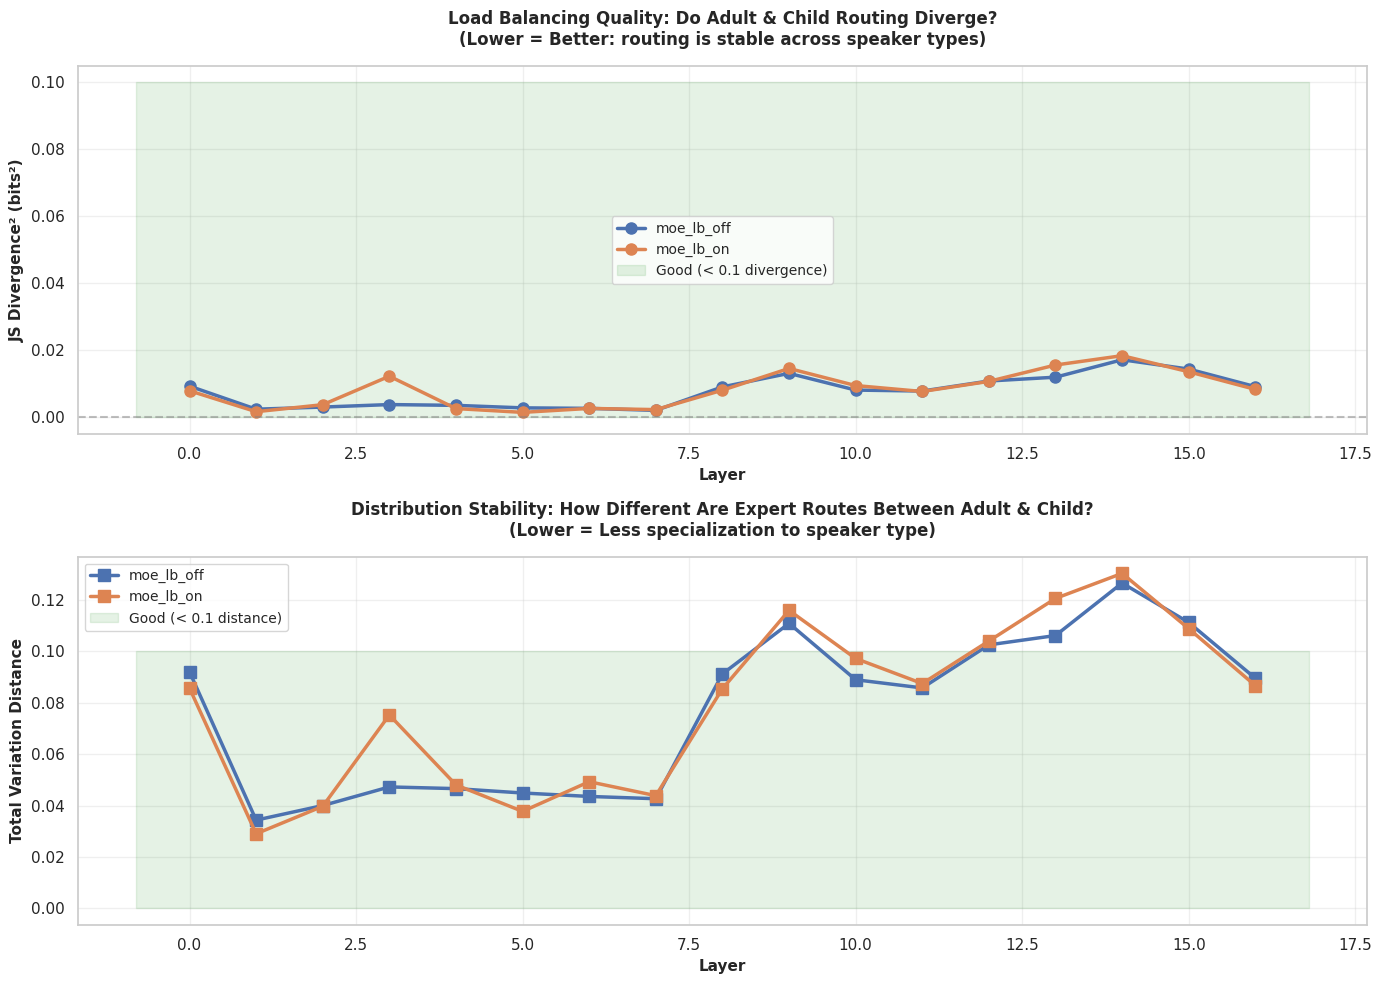


INTERPRETATION: Load Balancing Across Speaker Types

moe_lb_off:
  → Mean JS divergence: 0.0078 (GOOD - balanced routing)
  → Mean TV distance: 0.0766
  → Layers with significant divergence: 17/17

moe_lb_on:
  → Mean JS divergence: 0.0084 (GOOD - balanced routing)
  → Mean TV distance: 0.0790
  → Layers with significant divergence: 17/17


In [17]:
if not stats_df.empty:
    # Q: Does load-balance-off have WORSE load balancing than load-balance-on?
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: JS Divergence (lower = more balanced across adult/child routing)
    ax = axes[0]
    for ckpt in stats_df["checkpoint"].unique():
        data = stats_df[stats_df["checkpoint"] == ckpt]
        ax.plot(data["layer"], data["js_divergence"], marker="o", linewidth=2.5, label=ckpt, markersize=8)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.fill_between(ax.get_xlim(), 0, 0.1, alpha=0.1, color="green", label="Good (< 0.1 divergence)")
    ax.set_xlabel("Layer", fontsize=11, fontweight="bold")
    ax.set_ylabel("JS Divergence² (bits²)", fontsize=11, fontweight="bold")
    ax.set_title("Load Balancing Quality: Do Adult & Child Routing Diverge?\n(Lower = Better: routing is stable across speaker types)", 
                 fontsize=12, fontweight="bold", pad=15)
    ax.legend(fontsize=10, loc="best")
    ax.grid(True, alpha=0.3)
    
    # Plot 2: TV Distance (total variation between distributions)
    ax = axes[1]
    for ckpt in stats_df["checkpoint"].unique():
        data = stats_df[stats_df["checkpoint"] == ckpt]
        ax.plot(data["layer"], data["tv_distance"], marker="s", linewidth=2.5, label=ckpt, markersize=8)
    ax.fill_between(ax.get_xlim(), 0, 0.1, alpha=0.1, color="green", label="Good (< 0.1 distance)")
    ax.set_xlabel("Layer", fontsize=11, fontweight="bold")
    ax.set_ylabel("Total Variation Distance", fontsize=11, fontweight="bold")
    ax.set_title("Distribution Stability: How Different Are Expert Routes Between Adult & Child?\n(Lower = Less specialization to speaker type)", 
                 fontsize=12, fontweight="bold", pad=15)
    ax.legend(fontsize=10, loc="best")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation
    print("\n" + "="*80)
    print("INTERPRETATION: Load Balancing Across Speaker Types")
    print("="*80)
    for ckpt in sorted(stats_df["checkpoint"].unique()):
        data = stats_df[stats_df["checkpoint"] == ckpt]
        mean_js = data["js_divergence"].mean()
        mean_tv = data["tv_distance"].mean()
        sig_count = data["significant_bonf_0.05"].sum()
        print(f"\n{ckpt}:")
        print(f"  → Mean JS divergence: {mean_js:.4f} {'(POOR - high specialization)' if mean_js > 0.15 else '(GOOD - balanced routing)'}")
        print(f"  → Mean TV distance: {mean_tv:.4f}")
        print(f"  → Layers with significant divergence: {sig_count}/{len(data)}")


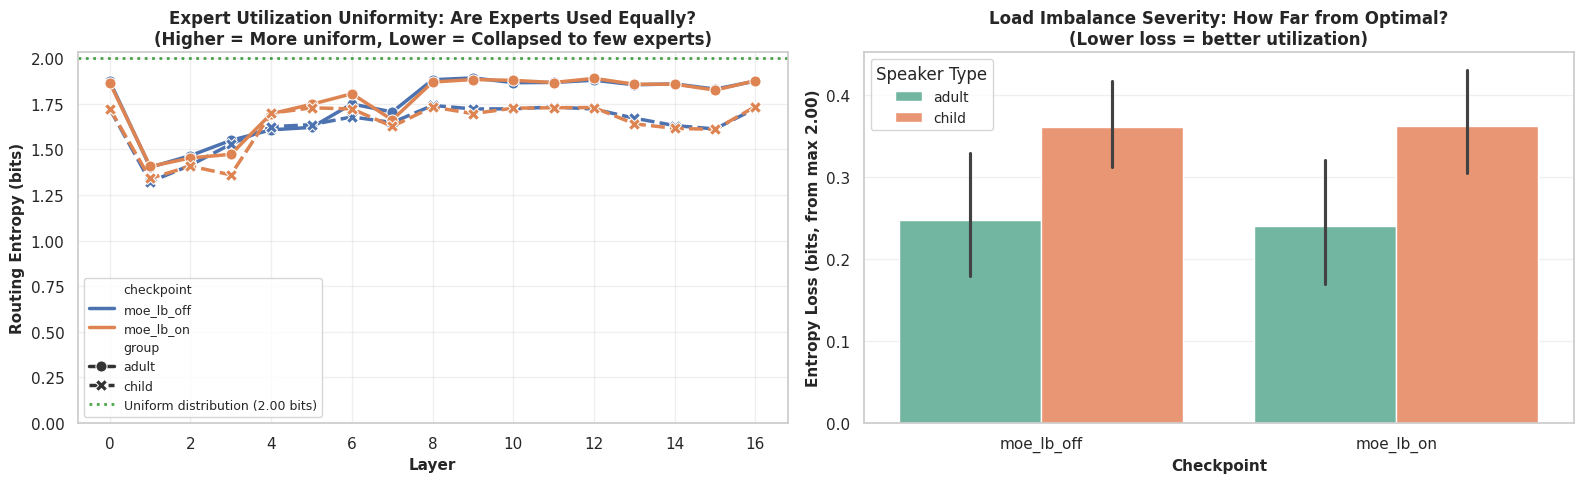


INTERPRETATION: Expert Utilization Patterns

moe_lb_off (adult):
  → Mean entropy: 1.752 bits
  → Utilization efficiency: 87.6% (GOOD - well balanced)

moe_lb_off (child):
  → Mean entropy: 1.639 bits
  → Utilization efficiency: 81.9% (GOOD - well balanced)

moe_lb_on (adult):
  → Mean entropy: 1.760 bits
  → Utilization efficiency: 88.0% (GOOD - well balanced)

moe_lb_on (child):
  → Mean entropy: 1.637 bits
  → Utilization efficiency: 81.8% (GOOD - well balanced)


In [18]:
if not entropy_df.empty:
    # Q: Which checkpoint maintains more uniform expert utilization? (Higher entropy = more uniform)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: Raw entropy by checkpoint + speaker type
    ax = axes[0]
    sns.lineplot(
        data=entropy_df,
        x="layer",
        y="entropy",
        hue="checkpoint",
        style="group",
        markers=True,
        ax=ax,
        linewidth=2.5,
        markersize=8,
    )
    max_entropy = np.log2(4)  # 4 experts
    ax.axhline(y=max_entropy, color="green", linestyle=":", linewidth=2, label=f"Uniform distribution ({max_entropy:.2f} bits)", alpha=0.7)
    ax.set_xlabel("Layer", fontsize=11, fontweight="bold")
    ax.set_ylabel("Routing Entropy (bits)", fontsize=11, fontweight="bold")
    ax.set_title("Expert Utilization Uniformity: Are Experts Used Equally?\n(Higher = More uniform, Lower = Collapsed to few experts)", 
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    
    # Right: Entropy gap from maximum (how much are we losing efficiency?)
    ax = axes[1]
    entropy_df["entropy_loss"] = max_entropy - entropy_df["entropy"]
    sns.barplot(
        data=entropy_df,
        x="checkpoint",
        y="entropy_loss",
        hue="group",
        ax=ax,
        palette="Set2",
    )
    ax.set_xlabel("Checkpoint", fontsize=11, fontweight="bold")
    ax.set_ylabel(f"Entropy Loss (bits, from max {max_entropy:.2f})", fontsize=11, fontweight="bold")
    ax.set_title("Load Imbalance Severity: How Far from Optimal?\n(Lower loss = better utilization)", 
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10, title="Speaker Type")
    ax.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation
    print("\n" + "="*80)
    print("INTERPRETATION: Expert Utilization Patterns")
    print("="*80)
    for ckpt in sorted(entropy_df["checkpoint"].unique()):
        for group in sorted(entropy_df["group"].unique()):
            data = entropy_df[(entropy_df["checkpoint"] == ckpt) & (entropy_df["group"] == group)]
            if not data.empty:
                mean_ent = data["entropy"].mean()
                efficiency = (mean_ent / max_entropy) * 100
                print(f"\n{ckpt} ({group}):")
                print(f"  → Mean entropy: {mean_ent:.3f} bits")
                print(f"  → Utilization efficiency: {efficiency:.1f}% {'(GOOD - well balanced)' if efficiency > 75 else '(POOR - experts underused)'}")



EXPERT UTILIZATION PATTERNS: Which experts are being overused/underused?

--- moe_lb_off ---


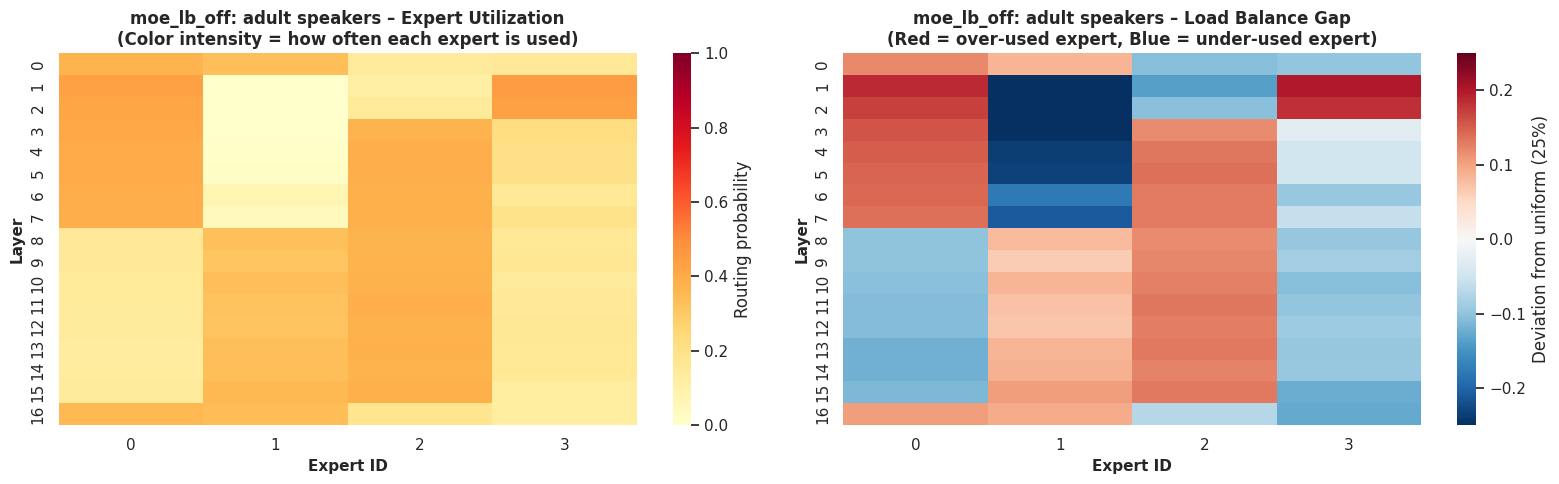

  adult: Gini-like imbalance metric = 0.2469 (concerning)


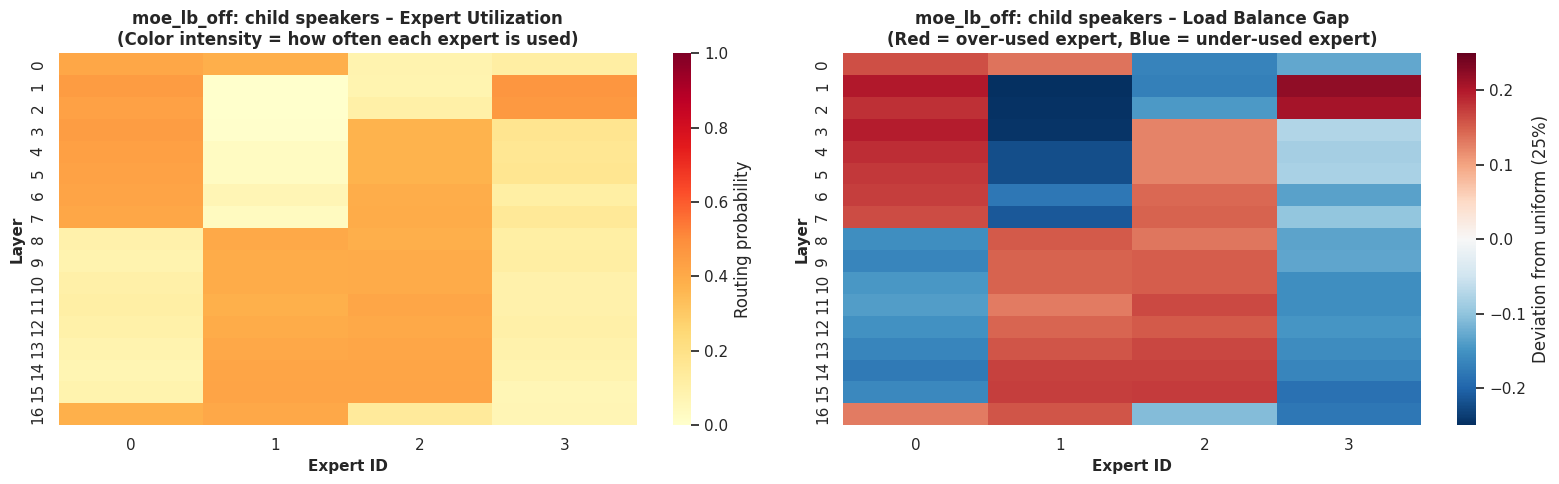

  child: Gini-like imbalance metric = 0.3203 (concerning)

--- moe_lb_on ---


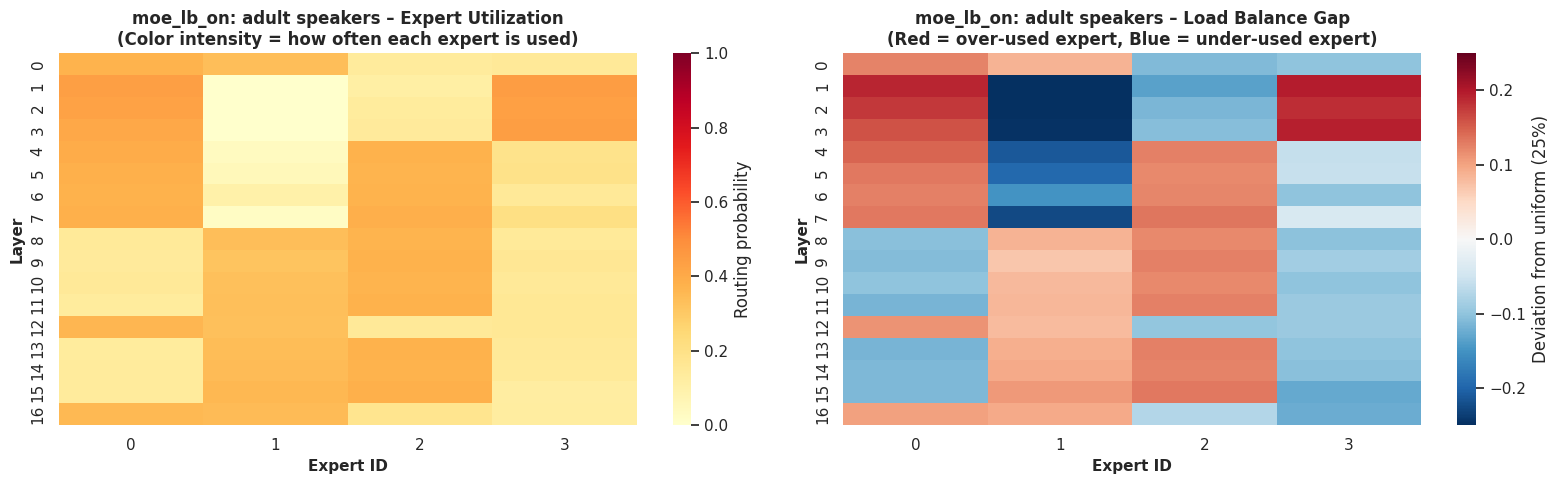

  adult: Gini-like imbalance metric = 0.2487 (concerning)


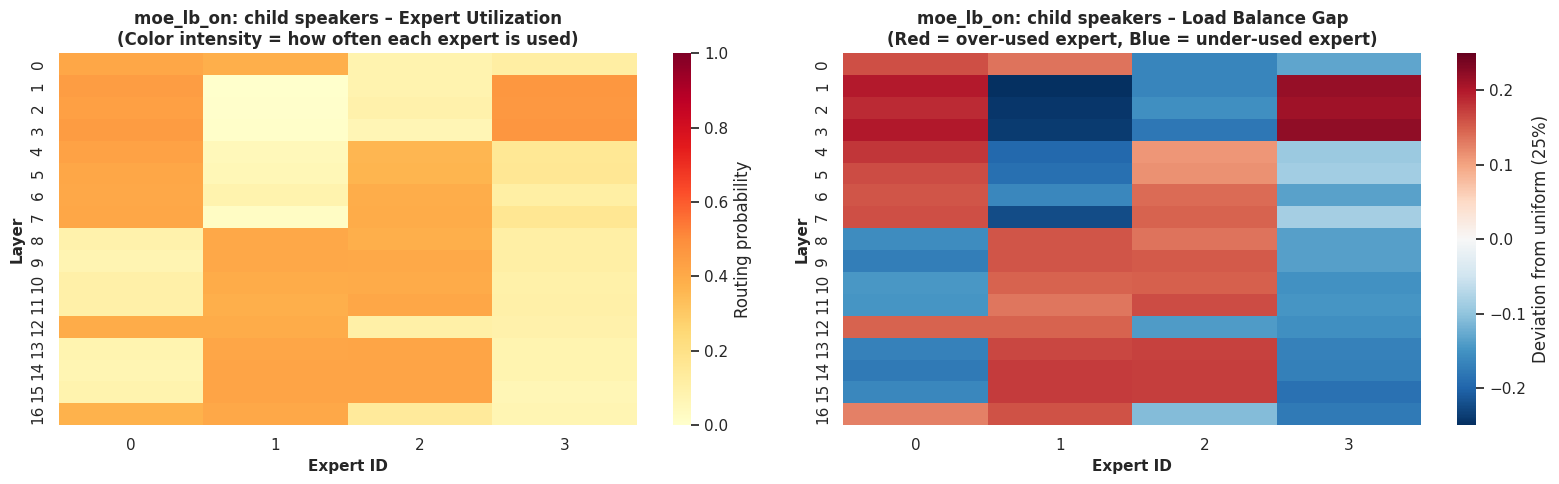

  child: Gini-like imbalance metric = 0.3244 (concerning)


In [19]:
def heatmap_for(checkpoint: str, group: str):
    """Show expert utilization vs. ideal uniform distribution."""
    required = {"checkpoint", "group", "layer", "expert", "prob"}
    if layer_probs_df.empty or not required.issubset(set(layer_probs_df.columns)):
        print("No routing probability data available for heatmap.")
        return

    d = layer_probs_df[(layer_probs_df["checkpoint"] == checkpoint) & (layer_probs_df["group"] == group)].copy()
    if d.empty:
        print(f"No data for checkpoint={checkpoint}, group={group}")
        return

    pivot = d.pivot(index="layer", columns="expert", values="prob").sort_index()
    
    # Compute deviation from uniform (expected = 0.25 for 4 experts)
    uniform_prob = 1.0 / pivot.shape[1]
    deviation = pivot - uniform_prob
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left: Actual utilization
    ax = axes[0]
    sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Routing probability"}, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{checkpoint}: {group} speakers – Expert Utilization\n(Color intensity = how often each expert is used)", 
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Expert ID", fontsize=11, fontweight="bold")
    ax.set_ylabel("Layer", fontsize=11, fontweight="bold")
    
    # Right: Deviation from uniform
    ax = axes[1]
    sns.heatmap(deviation, cmap="RdBu_r", center=0, cbar_kws={"label": "Deviation from uniform (25%)"}, ax=ax,
                vmin=-0.25, vmax=0.25)
    ax.set_title(f"{checkpoint}: {group} speakers – Load Balance Gap\n(Red = over-used expert, Blue = under-used expert)", 
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Expert ID", fontsize=11, fontweight="bold")
    ax.set_ylabel("Layer", fontsize=11, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("EXPERT UTILIZATION PATTERNS: Which experts are being overused/underused?")
print("="*80)

for ckpt_name in sorted(CHECKPOINTS.keys()):
    print(f"\n--- {ckpt_name} ---")
    for group in ["adult", "child"]:
        heatmap_for(ckpt_name, group)
        
        # Compute imbalance metric  
        d = layer_probs_df[(layer_probs_df["checkpoint"] == ckpt_name) & (layer_probs_df["group"] == group)]
        if not d.empty:
            pivot = d.pivot(index="layer", columns="expert", values="prob").sort_index()
            gini = np.nanmean([2 * np.abs(p).mean() for p in (pivot - 0.25).values])
            print(f"  {group}: Gini-like imbalance metric = {gini:.4f} {'(GOOD)' if gini < 0.1 else '(concerning)'}")


In [20]:
OUT_DIR = Path("./routing_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

stats_out = OUT_DIR / "layer_stats.csv"
entropy_out = OUT_DIR / "entropy_stats.csv"
probs_out = OUT_DIR / "layer_probs.csv"

if not stats_df.empty:
    stats_df.to_csv(stats_out, index=False)
if not entropy_df.empty:
    entropy_df.to_csv(entropy_out, index=False)
if not layer_probs_df.empty:
    layer_probs_df.to_csv(probs_out, index=False)

print(f"Wrote: {stats_out if stats_out.exists() else 'no stats'}")
print(f"Wrote: {entropy_out if entropy_out.exists() else 'no entropy'}")
print(f"Wrote: {probs_out if probs_out.exists() else 'no probs'}")

Wrote: routing_outputs/layer_stats.csv
Wrote: routing_outputs/entropy_stats.csv
Wrote: routing_outputs/layer_probs.csv



RESEARCH QUESTION: Do MoE experts implicitly specialize for child speech?


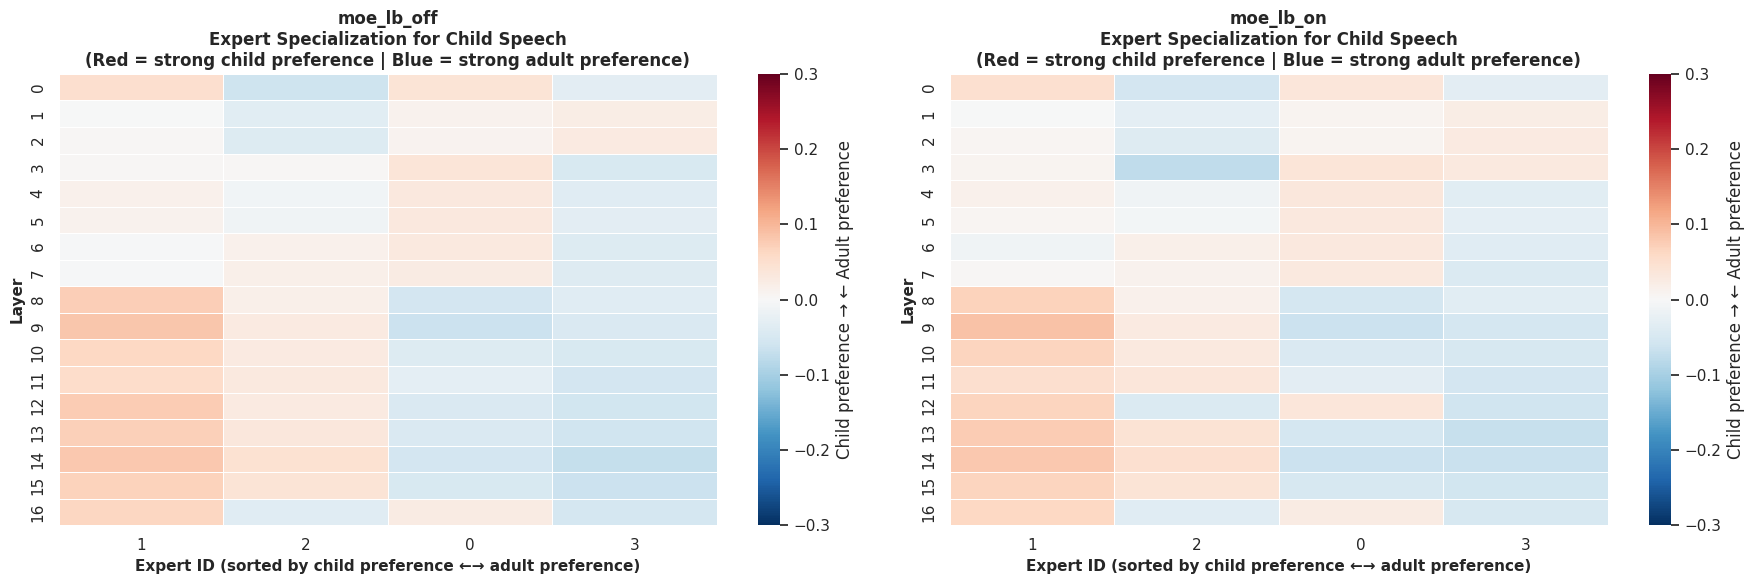


------------------------------------------------------------------------------------------
SPECIALIZATION METRICS (per checkpoint):
------------------------------------------------------------------------------------------

moe_lb_off:
  → Max child preference (any expert in any layer): +0.083
  → Max adult preference (any expert in any layer): +0.071
  → Mean specialization magnitude: 0.038

  Expert specialization ranking (avg across layers):
    Expert 1: +0.042 (Balanced)
    Expert 2: +0.005 (Balanced)
    Expert 0: -0.008 (Balanced)
    Expert 3: -0.040 (Balanced)

moe_lb_on:
  → Max child preference (any expert in any layer): +0.089
  → Max adult preference (any expert in any layer): +0.075
  → Mean specialization magnitude: 0.040

  Expert specialization ranking (avg across layers):
    Expert 1: +0.041 (Balanced)
    Expert 2: -0.001 (Balanced)
    Expert 0: -0.005 (Balanced)
    Expert 3: -0.035 (Balanced)

--------------------------------------------------------------------

In [22]:

# EXPERT SPECIALIZATION ANALYSIS: Do experts implicitly prefer child speech?

print("\n" + "="*90)
print("RESEARCH QUESTION: Do MoE experts implicitly specialize for child speech?")
print("="*90)

if layer_probs_df.empty:
    print("No routing probability data available.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    for idx, ckpt_name in enumerate(sorted(CHECKPOINTS.keys())):
        ax = axes[idx]
        
        # Compute expert preference: (child_prob - adult_prob) across all layers
        d = layer_probs_df[layer_probs_df["checkpoint"] == ckpt_name].copy()
        
        # Pivot to get adult and child probs by layer & expert
        adult_pivot = d[d["group"] == "adult"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        child_pivot = d[d["group"] == "child"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        
        # Compute specialization: positive = prefers child, negative = prefers adult
        specialization = child_pivot - adult_pivot
        
        # Sort by average specialization per expert (most child-preferring at top)
        expert_avg_spec = specialization.mean(axis=0).sort_values(ascending=False)
        specialization_sorted = specialization[expert_avg_spec.index]
        
        sns.heatmap(
            specialization_sorted,
            cmap="RdBu_r",
            center=0,
            ax=ax,
            cbar_kws={"label": "Child preference → ← Adult preference"},
            vmin=-0.3,
            vmax=0.3,
            annot=False,
            linewidths=0.5,
        )
        
        ax.set_xlabel("Expert ID (sorted by child preference ←→ adult preference)", fontsize=11, fontweight="bold")
        ax.set_ylabel("Layer", fontsize=11, fontweight="bold")
        ax.set_title(
            f"{ckpt_name}\nExpert Specialization for Child Speech\n"
            f"(Red = strong child preference | Blue = strong adult preference)",
            fontsize=12,
            fontweight="bold"
        )
    
    plt.tight_layout()
    plt.show()
    
    # Quantify specialization
    print("\n" + "-"*90)
    print("SPECIALIZATION METRICS (per checkpoint):")
    print("-"*90)
    
    for ckpt_name in sorted(CHECKPOINTS.keys()):
        d = layer_probs_df[layer_probs_df["checkpoint"] == ckpt_name].copy()
        
        adult_pivot = d[d["group"] == "adult"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        child_pivot = d[d["group"] == "child"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        specialization = child_pivot - adult_pivot
        
        # Metrics
        max_child_pref = specialization.values.max()
        max_adult_pref = -specialization.values.min()
        mean_abs_spec = specialization.abs().mean().mean()
        
        print(f"\n{ckpt_name}:")
        print(f"  → Max child preference (any expert in any layer): {max_child_pref:+.3f}")
        print(f"  → Max adult preference (any expert in any layer): {max_adult_pref:+.3f}")
        print(f"  → Mean specialization magnitude: {mean_abs_spec:.3f}")
        
        # Identify most specialized experts
        expert_avg_spec = specialization.mean(axis=0).sort_values(ascending=False)
        print(f"\n  Expert specialization ranking (avg across layers):")
        for expert, spec in expert_avg_spec.items():
            pref = "CHILD specialist" if spec > 0.05 else ("ADULT specialist" if spec < -0.05 else "Balanced")
            print(f"    Expert {int(expert)}: {spec:+.3f} ({pref})")

    print("\n" + "-"*90)
    print("INTERPRETATION:")
    print("-"*90)
    
    # Compare the two checkpoints
    for ckpt_name in sorted(CHECKPOINTS.keys()):
        d = layer_probs_df[layer_probs_df["checkpoint"] == ckpt_name].copy()
        adult_pivot = d[d["group"] == "adult"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        child_pivot = d[d["group"] == "child"].pivot(index="layer", columns="expert", values="prob").fillna(0)
        specialization = child_pivot - adult_pivot
        mean_abs_spec = specialization.abs().mean().mean()
        
        if mean_abs_spec > 0.1:
            print(f"\n✓ {ckpt_name}: STRONG implicit specialization detected")
            print(f"  → Experts show clear preferences for child vs adult speakers")
        elif mean_abs_spec > 0.05:
            print(f"\n⚠ {ckpt_name}: MODERATE implicit specialization")
            print(f"  → Some experts show preferences, but not overwhelmingly")
        else:
            print(f"\n✗ {ckpt_name}: MINIMAL implicit specialization")
            print(f"  → Experts route similarly regardless of speaker age")
